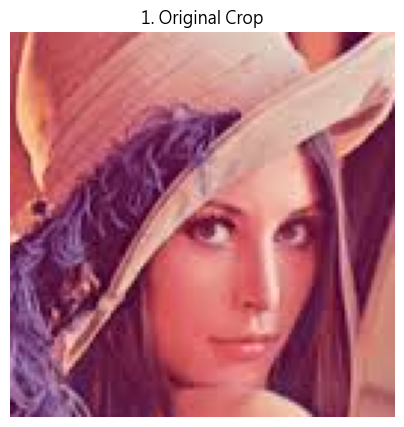

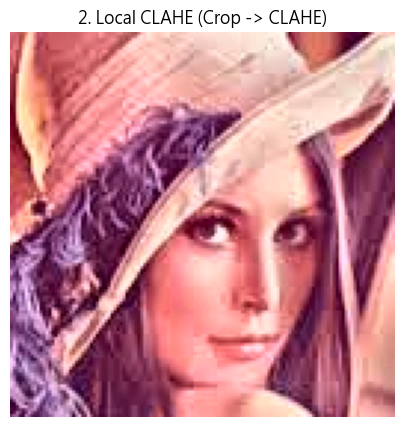

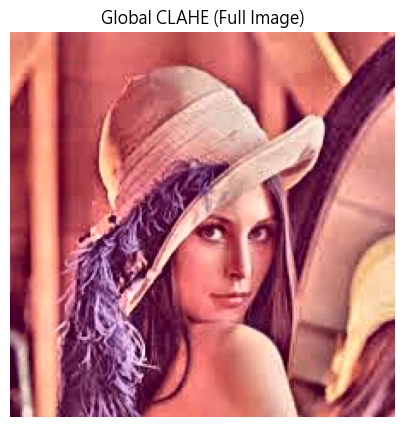

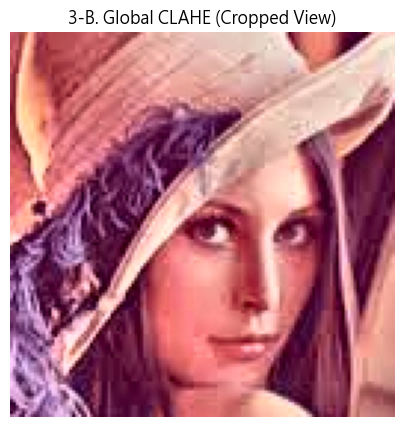

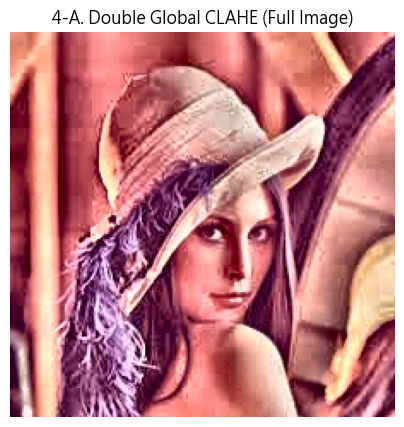

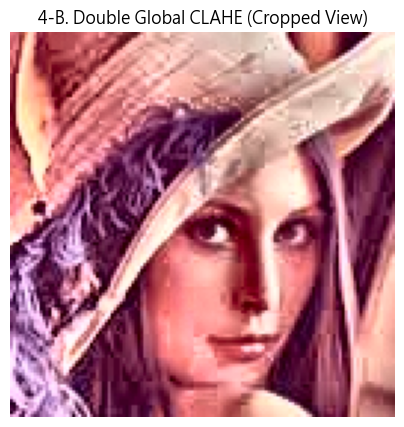

: 

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Set figsize for clearer individual images
plt.rcParams['figure.figsize'] = [5, 5]

def apply_clahe_color(image, clip_limit=2.0, grid_size=(8, 8)):
    """
    Applies CLAHE to a color image (L channel only).
    """
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return final

# ==========================================
# Processing
# ==========================================

filename = 'lena.jpg'
img_bgr = cv2.imread(filename)

if img_bgr is None:
    print(f"Error: {filename} not found.")
else:
    # Convert to RGB
    img_orig = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # --- Crop Coordinates for 225x225 ---
    y_start, y_end = 50, 180
    x_start, x_end = 50, 180

    # 1. Original Crop
    img1_crop = img_orig[y_start:y_end, x_start:x_end]

    # 2. Local CLAHE (Crop first, then CLAHE)
    img2_local_clahe = apply_clahe_color(img1_crop)

    # 3. Global CLAHE (Full Image first)
    img_full_clahe_1st = apply_clahe_color(img_orig)         # <--- Full Image
    img3_global_clahe_crop = img_full_clahe_1st[y_start:y_end, x_start:x_end] # <--- Crop View

    # 4. Double Global CLAHE (Full Image CLAHE again)
    img_full_clahe_2nd = apply_clahe_color(img_full_clahe_1st) # <--- Full Image
    img4_double_clahe_crop = img_full_clahe_2nd[y_start:y_end, x_start:x_end] # <--- Crop View

    # ==========================================
    # Display All Images Separately
    # ==========================================

    # --- 1. Original Crop ---
    plt.figure()
    plt.imshow(img1_crop)
    plt.title("1. Original Crop")
    plt.axis('off')
    plt.show()

    # --- 2. Local CLAHE (Processed after cropping) ---
    plt.figure()
    plt.imshow(img2_local_clahe)
    plt.title("2. Local CLAHE (Crop -> CLAHE)")
    plt.axis('off')
    plt.show()

    # --- 3a. Global CLAHE (FULL IMAGE) --- (這是您要補的：只做CLAHE但不裁切)
    plt.figure()
    plt.imshow(img_full_clahe_1st)
    plt.title("Global CLAHE (Full Image)")
    plt.axis('off')
    plt.show()

    # --- 3b. Global CLAHE (Cropped View) ---
    plt.figure()
    plt.imshow(img3_global_clahe_crop)
    plt.title("3-B. Global CLAHE (Cropped View)")
    plt.axis('off')
    plt.show()

    # --- 4a. Double Global CLAHE (FULL IMAGE) ---
    plt.figure()
    plt.imshow(img_full_clahe_2nd)
    plt.title("4-A. Double Global CLAHE (Full Image)")
    plt.axis('off')
    plt.show()

    # --- 4b. Double Global CLAHE (Cropped View) ---
    plt.figure()
    plt.imshow(img4_double_clahe_crop)
    plt.title("4-B. Double Global CLAHE (Cropped View)")
    plt.axis('off')
    plt.show()